In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pingouin as pg

In [2]:
# combine different dictionary analyses into one df for south park
df_liwc_sp= pd.read_csv("sp_liwc22.csv")
df_stereo = pd.read_csv("sp_stereo_liwc.csv")
df_contra = pd.read_csv("sp_contra_liwc.csv")
df_ived = pd.read_csv("sp_ived_liwc.csv")

print(df_liwc_sp.columns)
stereo_cols = ['Valence_Pos', 'Valence_Neg', 'Valence_Neut',
       'Sociability_Freq', 'Sociability_Direction', 'Morality_Freq',
       'Morality_Direction', 'Ability_Freq', 'Ability_Direction',
       'Agency_Freq', 'Agency_Direction', 'Health_Freq', 'Health_Direction',
       'Status_Freq', 'Status_Direction', 'Work_Freq', 'Work_Direction',
       'Politics_Freq', 'Politics_Direction', 'Religion_Freq',
       'Religion_Direction', 'Beliefs_Other_Freq', 'Beliefs_Other_Direction',
       'Inhabitant_Freq', 'Country_Freq', 'Feelings_Freq', 'Relatives_Freq',
       'Clothing_Freq', 'Ordinariness_Freq', 'Ordinariness_Direction',
       'Body_Part_Freq', 'Body_Property_Freq', 'Skin_Freq',
       'Body_Covering_Freq', 'Beauty_Freq', 'Beauty_Direction', 'Insults_Freq',
       'STEM_Freq', 'Humanities_Freq', 'Art_Freq', 'Social_Groups_Freq',
       'Lacks_Knowledge_Freq', 'Fortune_Freq'] # tbh this dictionary is confusing to work with
contra_cols = ['HighControversial', 'MediumControversial','LowControversial']
ived_col = 'IVED'
df_liwc_sp[stereo_cols] = df_stereo[stereo_cols].abs()
df_liwc_sp[contra_cols] = df_contra[contra_cols]
df_liwc_sp[ived_col] = df_ived[ived_col]
df_liwc_sp[stereo_cols + contra_cols] = df_liwc_sp[stereo_cols + contra_cols]/100
df_liwc_sp[ived_col] = df_liwc_sp[ived_col]/100
df_liwc_sp = df_liwc_sp.drop(columns= "Unnamed: 0")

# relevent measures: contraversial, ived, valence_neg, swear, sexual, substance, politics_freq +direction, religion_freq + direction, insults_freq
df_liwc_sp.head()

Index(['Unnamed: 0', 'Season', 'Episode', 'Character', 'Line', 'Segment', 'WC',
       'Analytic', 'Clout', 'Authentic', 'Tone', 'WPS', 'BigWords', 'Dic',
       'Linguistic', 'function', 'pronoun', 'det', 'prep', 'auxverb', 'adverb',
       'conj', 'negate', 'verb', 'adj', 'quantity', 'Affect', 'tone_pos',
       'tone_neg', 'emotion', 'emo_pos', 'emo_neg', 'emo_anx', 'emo_anger',
       'emo_sad', 'swear', 'Social', 'socbehav', 'prosocial', 'polite',
       'conflict', 'moral', 'comm', 'Physical', 'substances', 'sexual',
       'death'],
      dtype='object')


,Season,Episode,Character,Line,Segment,WC,Analytic,Clout,Authentic,Tone,...,STEM_Freq,Humanities_Freq,Art_Freq,Social_Groups_Freq,Lacks_Knowledge_Freq,Fortune_Freq,HighControversial,MediumControversial,LowControversial,IVED
0,10,1,Stan,"You guys, you guys! Chef is going away.",1,8,26.10,99.00,89.39,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2500,0.0
1,10,1,Kyle,Going away? For how long?,1,5,99.00,NaN,99.00,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0
2,10,1,Stan,Forever.,1,1,NaN,NaN,99.00,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0
3,10,1,Chef,I'm sorry boys.,1,3,1.00,40.06,99.00,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3333,0.0
4,10,1,Stan,"Chef said he's been bored, so he joining a gro...",1,15,22.17,99.00,1.00,97.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0667,0.0


In [8]:
print(len(['Valence_Pos', 'Valence_Neg', 'Valence_Neut', 'Sociability_Freq', 'Morality_Freq', 'Ability_Freq', 'Agency_Freq', 'Health_Freq', 'Status_Freq', 'Work_Freq', 'Politics_Freq', 'Religion_Freq', 'Beliefs_Other_Freq', 'Inhabitant_Freq', 'Country_Freq', 'Feelings_Freq', 'Relatives_Freq', 'Clothing_Freq', 'Ordinariness_Freq', 'Body_Part_Freq', 'Body_Property_Freq', 'Skin_Freq', 'Body_Covering_Freq', 'Beauty_Freq', 'Insults_Freq', 'STEM_Freq', 'Humanities_Freq', 'Art_Freq', 'Social_Groups_Freq', 'Lacks_Knowledge_Freq', 'Fortune_Freq', 'HighControversial', 'MediumControversial', 'LowControversial', 'Affect', 'tone_pos', 'tone_neg', 'emotion', 'emo_pos', 'emo_neg', 'emo_anx', 'emo_anger', 'emo_sad', 'swear', 'Social', 'socbehav', 'prosocial', 'polite', 'conflict', 'moral', 'comm', 'Physical', 'substances', 'sexual', 'death', 'IVED']))

56


In [3]:
# combine different csvs for family guy
# combine different dictionary analyses into one df for south park
df_liwc_fg= pd.read_csv("fg_liwc22.csv")
df_stereo = pd.read_csv("fg_stereo_liwc.csv")
df_contra = pd.read_csv("fg_contra_liwc.csv")
df_ived = pd.read_csv("fg_ived_liwc.csv")

df_liwc_fg[stereo_cols] = df_stereo[stereo_cols].abs()
df_liwc_fg[contra_cols] = df_contra[contra_cols]
df_liwc_fg[ived_col] = df_ived[ived_col]
df_liwc_fg[stereo_cols + contra_cols] = df_liwc_fg[stereo_cols + contra_cols]/100
df_liwc_fg[ived_col] = df_liwc_fg[ived_col]/100
df_liwc_fg = df_liwc_fg.rename(columns = {"Dialogue": "Line"})
# relevent measures: contraversial, ived, valence_neg, swear, sexual, substance, politics_freq +direction, religion_freq + direction, insults_freq

In [4]:
# basic processing SP
df_liwc_sp = df_liwc_sp[df_liwc_sp["Episode"] != "Episode"]
df_liwc_sp = df_liwc_sp[df_liwc_sp["Season"] != "Season"]

df_liwc_sp = df_liwc_sp[~df_liwc_sp['Line'].isna()]
df_liwc_sp['Episode'] = df_liwc_sp['Episode'].astype(int)
df_liwc_sp['Season'] = df_liwc_sp['Season'].astype(int) 

# remove lines that are <= 3 words (following same filtering as classification analysis)
df_liwc_sp['split_line'] = df_liwc_sp['Line'].str.split().apply(lambda x: [word for word in x if word.strip() != ""])
df_liwc_sp['line_len'] = df_liwc_sp['split_line'].apply(len)
df_liwc_sp = df_liwc_sp[df_liwc_sp['line_len'] > 3]

# basic processing FG
df_liwc_fg = df_liwc_fg[df_liwc_fg["Episode"] != "Episode"]
df_liwc_fg = df_liwc_fg[df_liwc_fg["Season"] != "Season"]
df_liwc_fg = df_liwc_fg[~df_liwc_fg['Line'].isna()]
df_liwc_fg['Episode'] = df_liwc_fg['Episode'].astype(int)
df_liwc_fg['Season'] = df_liwc_fg['Season'].astype(int) 

# remove lines that are <= 3 words (following same filtering as classification analysis)
df_liwc_fg['split_line'] = df_liwc_fg['Line'].str.split().apply(lambda x: [word for word in x if word.strip() != ""])
df_liwc_fg['line_len'] = df_liwc_fg['split_line'].apply(len)
df_liwc_fg = df_liwc_fg[df_liwc_fg['line_len'] > 3]

df_liwc_fg.to_csv("fg_all_liwc.csv")
df_liwc_sp.to_csv("sp_all_liwc.csv")


In [5]:
def plot_episodes(df, metric):
    episode_means = df.groupby(['Season', 'Episode'])[metric].mean().reset_index()
    episode_means = episode_means.sort_values(by=['Season', 'Episode'])

    # Create a continuous x-axis (indexing episodes chronologically)
    episode_means['x'] = range(len(episode_means))  # Create a sequential x-axis

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(episode_means['x'], episode_means[metric], marker='o', linestyle='-', label="Negative Line Proportion")

    # Customize X-axis labels
    plt.xticks(episode_means['x'], labels=[f"S{s}E{e}" for s, e in zip(episode_means['Season'], episode_means['Episode'])], rotation=45)

    # Labels and Title
    plt.xlabel("Episode (aChronological Order)")
    plt.ylabel(f"Mean LWIC {metric} rating")
    plt.title(f"Mean LIWC {metric} rating by Episode")
    plt.legend()

    plt.show()

plot_episodes(df_liwc_sp, "swear")

TypeError: plot_episodes() missing 1 required positional argument: 'metric'

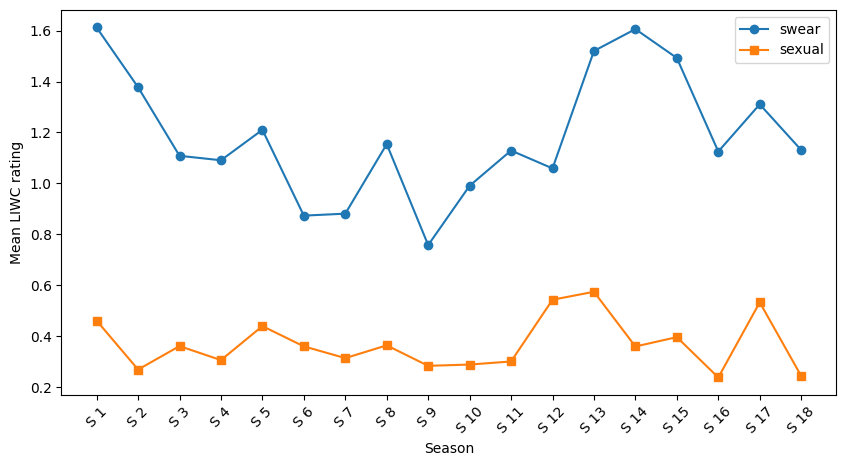

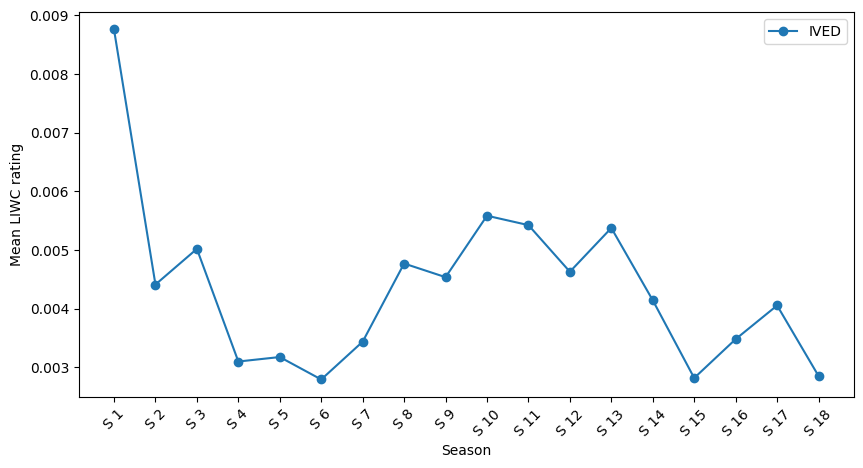

In [ ]:
# plot for south park

# plotting for bad words
metrics = ["swear", "sexual", "IVED", "tone_neg", "Religion_Direction", "Politics_Direction", "death"]
sp_season_means = df_liwc_sp.groupby('Season')[metrics].mean().reset_index()
sp_season_means = sp_season_means.sort_values(by=['Season'])
sp_season_means["year"] = list(range(1997, 2015))

# Create a continuous x-axis (indexing episodes chronologically)
sp_season_means['x'] = range(len(sp_season_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(sp_season_means['x'], sp_season_means[metrics[0]], marker='o', linestyle='-', label=metrics[0])
plt.plot(sp_season_means['x'], sp_season_means[metrics[1]], marker='s', linestyle='-', label=metrics[1])

# Customize X-axis labels
plt.xticks(sp_season_means['x'], labels=[f"S {s}" for s in sp_season_means['Season']], rotation=45)

# Labels and Title
plt.xlabel("Season")
plt.ylabel(f"Mean LIWC rating")
plt.legend()
plt.show()

#plotting for political/group reference

plt.figure(figsize=(10, 5))
plt.plot(sp_season_means['x'], sp_season_means["IVED"], marker='o', linestyle='-', label="IVED")

# Customize X-axis labels
plt.xticks(sp_season_means['x'], labels=[f"S {s}" for s in sp_season_means['Season']], rotation=45)

# Labels and Title
plt.xlabel("Season")
plt.ylabel(f"Mean LIWC rating")
plt.legend()
plt.show()

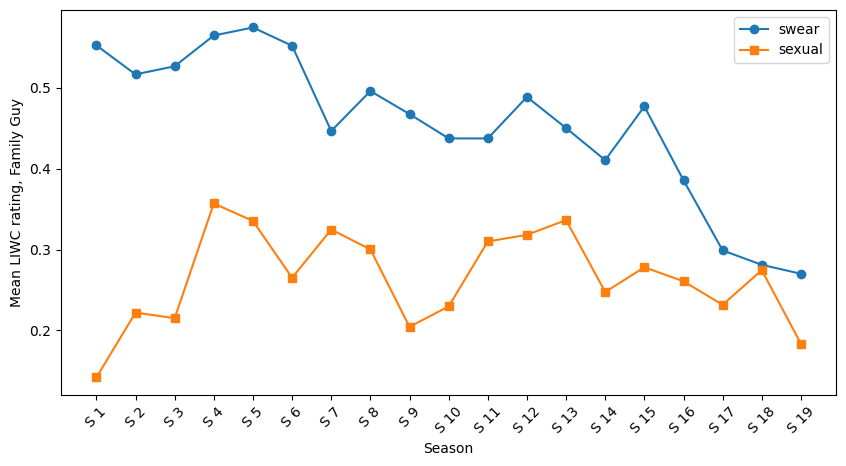

In [65]:
# plot for family guy

metrics = ["swear", "sexual", "IVED", "tone_neg", "Religion_Direction", "Politics_Direction"]
fg_season_means = df_liwc_fg.groupby('Season')[metrics].mean().reset_index()
fg_season_means = fg_season_means.sort_values(by=['Season'])
fg_season_means["year"] = list(range(1999, 2018))

# Create a continuous x-axis (indexing episodes chronologically)
fg_season_means['x'] = range(len(fg_season_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(fg_season_means['x'], fg_season_means[metrics[0]], marker='o', linestyle='-', label=metrics[0])
plt.plot(fg_season_means['x'], fg_season_means[metrics[1]], marker='s', linestyle='-', label=metrics[1])
plt.plot(fg_season_means['x'], fg_season_means[metrics[2]], marker='*', linestyle='-', label=metrics[2])

# Customize X-axis labels
plt.xticks(fg_season_means['x'], labels=[f"S {s}" for s in fg_season_means['Season']], rotation=45)

# Labels and Title
plt.xlabel("Season")
plt.ylabel(f"Mean LIWC rating, Family Guy")
plt.legend()
plt.show()

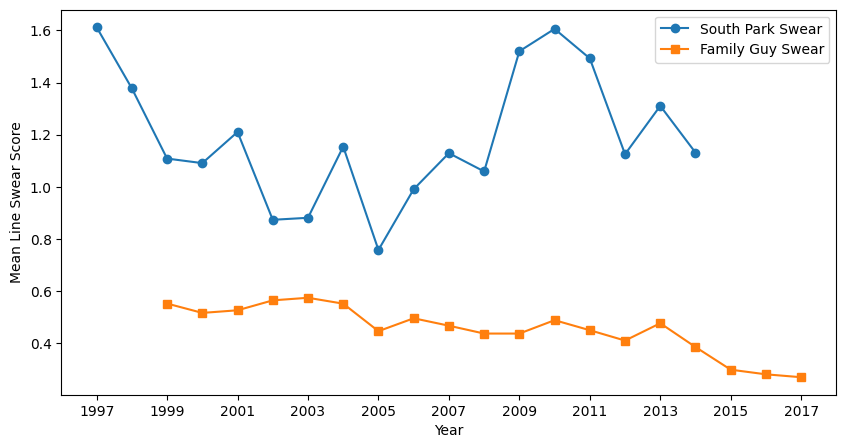

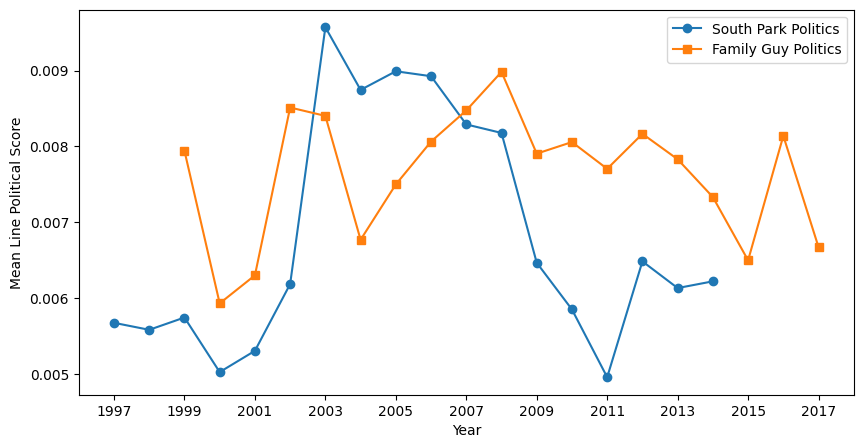

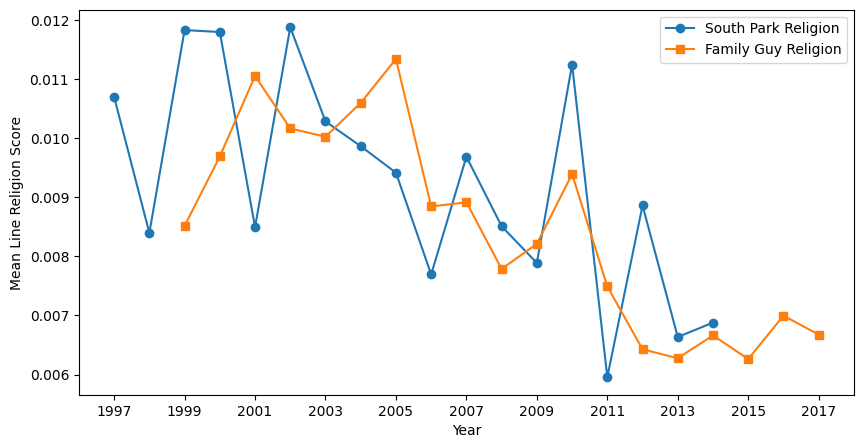

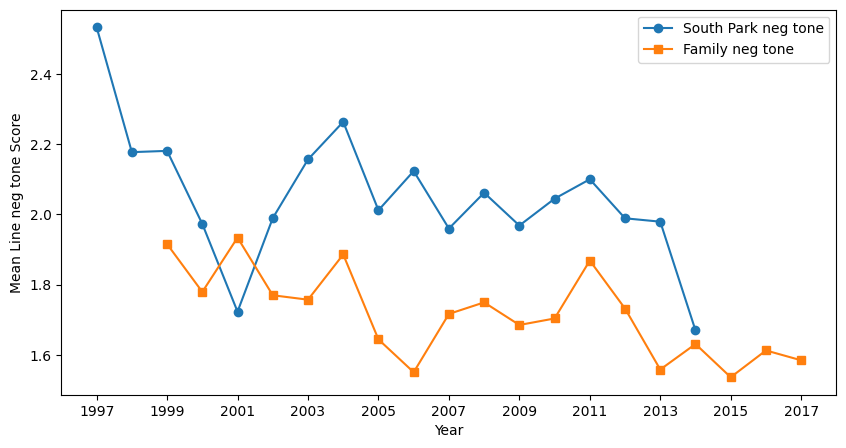

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["swear"], marker='o', linestyle='-', label="South Park Swear")
plt.plot(fg_season_means["year"], fg_season_means["swear"], marker='s', linestyle='-', label="Family Guy Swear")

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line Swear Score")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["Politics_Direction"], marker='o', linestyle='-', label="South Park Politics")
plt.plot(fg_season_means["year"], fg_season_means["Politics_Direction"], marker='s', linestyle='-', label="Family Guy Politics")

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line Political Score")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["Religion_Direction"], marker='o', linestyle='-', label="South Park Religion")
plt.plot(fg_season_means["year"], fg_season_means["Religion_Direction"], marker='s', linestyle='-', label="Family Guy Religion")

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line Religion Score")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["tone_neg"], marker='o', linestyle='-', label="South Park neg tone")
plt.plot(fg_season_means["year"], fg_season_means["tone_neg"], marker='s', linestyle='-', label="Family neg tone")

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line neg tone Score")
plt.legend()
plt.show()

In [9]:
# want to know which seasons are most statistically different for SOUTH PARK

# Data is not normally distributed and can't be easily sorted into 0/1 categories: use Mann-Whitney U
def mwu_test(df, metric, s1, s2):
    s1_data = df.loc[df["Season"] == s1, metric]
    s2_data = df.loc[df["Season"] == s2, metric]
    test = pg.mwu(s1_data, s2_data)
    return test["p-val"].iloc[0]

def compare_consecutive_means(df, metric):
    pvals = pd.DataFrame({"s1": [], "s2": [], "pval": []})

    # get mwu tests for every consecutive season pair
    for i in range (1, len(df["Season"].unique())):
        pval = mwu_test(df, metric, i, i+1)
        pvals.loc[len(pvals)] = [i, i+1, pval]

    # apply holm correction
    pvals = pvals.sort_values(by = "pval", ascending = False)
    pvals["rank"] = range(1, len(pvals)+1)
    pvals["holm_pval"] = pvals["pval"] * pvals["rank"]
    pvals = pvals.drop(columns = 'rank')
    pvals = pvals.sort_index()

    return pvals

pvals_swear = compare_consecutive_means(df_liwc_sp, "swear")
pvals_sexual = compare_consecutive_means(df_liwc_sp, "sexual")
pvals_politics = compare_consecutive_means(df_liwc_sp, "Politics_Direction")
pvals_sp = pvals_swear
pvals_sp[["pval_sexual", "holm_pval_sexual"]] = pvals_sexual[["pval", "holm_pval"]]
pvals_sp[["pval_politics", "holm_pval_politics"]] = pvals_politics[["pval", "holm_pval"]]
pd.options.display.float_format = lambda x: f'{x:.5f}' if abs(x) >= 1e-5 and abs(x) < 1e5 else f'{x:.2e}'
pvals_sp



,s1,s2,pval,holm_pval,pval_sexual,holm_pval_sexual,pval_politics,holm_pval_politics
0,1.00000,2.00000,0.03568,0.39251,0.00294,0.03533,0.66490,3.32448
1,2.00000,3.00000,0.00684,0.08208,0.00001,0.00021,0.03666,0.47656
2,3.00000,4.00000,0.45011,2.25053,0.02365,0.21285,0.02671,0.40070
3,4.00000,5.00000,0.52555,1.57665,0.00025,0.00344,0.94646,2.83938
4,5.00000,6.00000,0.00087,0.01212,0.30307,1.51533,0.01209,0.19342
5,6.00000,7.00000,0.84503,0.84503,0.01369,0.13691,0.00002,0.00032
6,7.00000,8.00000,0.00335,0.04356,0.14949,1.04643,0.32343,3.55771
7,8.00000,9.00000,0.00013,0.00193,0.51525,1.54574,0.59022,4.13157
8,9.00000,10.00000,0.10751,0.96760,0.34447,1.37787,0.66429,3.98573
9,10.00000,11.00000,0.05744,0.57440,0.55725,1.11449,0.36973,3.32761


In [10]:
pvals_swear_fg = compare_consecutive_means(df_liwc_fg, "swear")
pvals_sexual_fg = compare_consecutive_means(df_liwc_fg, "sexual")
pvals_politics_fg = compare_consecutive_means(df_liwc_fg, "Politics_Direction")
pvals_fg = pvals_swear_fg
pvals_fg[["pval_sexual", "holm_pval_sexual"]] = pvals_sexual_fg[["pval", "holm_pval"]]
pvals_fg[["pval_politics", "holm_pval_politics"]] = pvals_politics_fg[["pval", "holm_pval"]]
pvals_fg



,s1,s2,pval,holm_pval,pval_sexual,holm_pval_sexual,pval_politics,holm_pval_politics
0,1.00000,2.00000,0.83530,1.67060,0.02721,0.29932,0.00028,0.00478
1,2.00000,3.00000,0.68390,3.41948,0.65989,2.63954,0.28158,2.53424
2,3.00000,4.00000,0.48190,5.30089,0.00498,0.06972,0.00003,0.00047
3,4.00000,5.00000,0.67279,4.03675,0.83218,0.83218,0.92686,0.92686
4,5.00000,6.00000,0.50865,5.08646,0.00451,0.06771,0.00247,0.03960
5,6.00000,7.00000,0.14659,2.05224,0.02307,0.27684,0.08539,1.11003
6,7.00000,8.00000,0.56865,5.11781,0.02057,0.26743,0.47912,3.35384
7,8.00000,9.00000,0.77832,2.33495,0.00061,0.01100,0.48533,2.91196
8,9.00000,10.00000,0.44309,5.31704,0.18587,1.30110,0.50897,2.03587
9,10.00000,11.00000,0.59684,4.77475,0.00305,0.05179,0.07458,1.04411


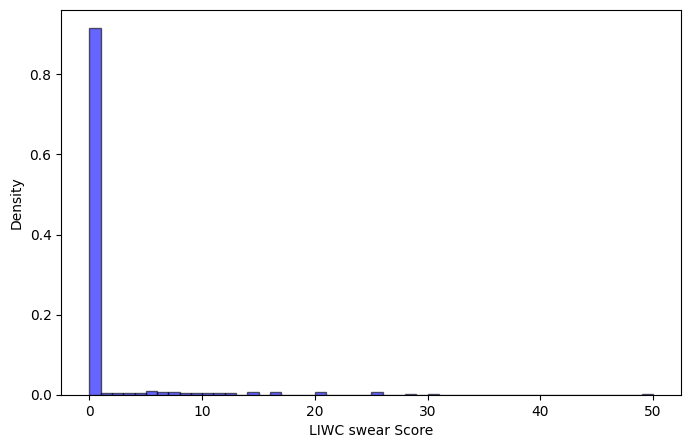

In [16]:
# distributions for appendix
def plot_liwc_hist(df, season, metric):
    season_data = df[df['Season'] == season]
    if season_data.empty:
        print(f"No data available for Season {season}.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.hist(season_data[metric], bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
    
    plt.xlabel(f"LIWC {metric} Score")
    plt.ylabel("Density")
    
    plt.show()
plot_liwc_hist(df_liwc_sp, 10, "swear")
# none of the distributions are normal
# if restricted to only looking at lines about 80 the distrib is more normal